# Spectral Clustering

## What Is Spectral Clustering?

**Spectral clustering** is a **graph-based** clustering method that converts the dataset into a similarity graph, reads its structure via the graph’s **Laplacian eigenvectors**, and then cuts the graph into $k$ parts that respect those eigenvector patterns.

The idea: translate geometric relationships into **graph connectivity**, use the graph’s spectrum to reveal **non-linear, manifold-shaped** clusters, and finally apply a simple algorithm (usually k-means) in that low-dimensional spectral space.

---

### How It Works

Conceptual pipeline (Ng–Jordan–Weiss recipe):

1. **Construct an affinity matrix** $A$
   *Typical choice:* radial basis function (RBF) kernel

   $$
   A_{ij} = \exp\!\bigl(-\lVert x_i - x_j \rVert^{2}/(2\sigma^{2})\bigr)
   $$

   or $k$-nearest-neighbor graph with binary edges.

2. **Form the graph Laplacian**

   $$
   L = D - A,\quad
   \mathcal{L}_{\text{sym}} = D^{-1/2}LD^{-1/2},\quad
   \mathcal{L}_{\text{rw}} = D^{-1}L
   $$

   where $D$ is the degree matrix.

3. **Compute the first $k$ eigenvectors** of the chosen Laplacian and stack them into $U\in\mathbb{R}^{n\times k}$.

4. **Row-normalize** $U$ (optional but common) to get $Z$.

5. **Cluster rows of $Z$** with k-means (or another algorithm) to obtain final labels.

---

### Why It Works

* Embedding points into the **eigenvector space** minimizes a relaxed version of the normalized-cut objective, favoring clusters with **many internal edges but few cross-edges**.
* The Laplacian’s eigenvectors faithfully describe **connectivity on non-convex manifolds** (e.g.\ moons, spirals) that frustrate distance-only methods like k-means.
* Row-normalization projects points onto a unit sphere, separating clusters by angular distance and amplifying cut quality.

---

### Variants & Tricks

| Variant / Library Feature       | Extra Twist & Benefit                                                  |
| ------------------------------- | ---------------------------------------------------------------------- |
| **Normalized-cut (Shi–Malik)**  | Uses random-walk Laplacian → interpretable as Markov ergodicity.       |
| **Ratio-cut / Unnormalized**    | Simpler math; works when degrees are roughly uniform.                  |
| **Self-tuning spectral**        | Adapts kernel width $\sigma_i$ per point → handles varying density.    |
| **Nyström / Landmark spectral** | Approximates eigenvectors using a sample → scalable to $10^5+$ points. |
| **Spectral Clustering on GPUs** | RAPIDS cuML implementation accelerates eigendecomposition.             |

---

### ⚠️ Pros and Cons

✅ Captures **arbitrary shapes** and clusters lying on intertwined manifolds.
✅ Requires only a **similarity definition**—works with cosine, RBF, mutual-reachability, etc.
✅ Provides an **interpretable graph view**; the eigenvalue gap hints at a natural $k$.

❌ **Eigen-decomposition** is $O(n^3)$ in the worst case—memory-heavy for large $n$.
❌ Sensitive to **affinity choices** (kernel type, $\sigma$, k-NN) and to feature scaling.
❌ Must still pick $k$ (or rely on spectrum heuristics).
❌ Produces dense affinity matrices unless sparsified—may limit size to a few tens of thousands of samples without approximations.

---

### Key Hyper-parameters (`sklearn.cluster.SpectralClustering`)

| Symbol in `sklearn` | Meaning                                                       | Typical starter value     |
| ------------------- | ------------------------------------------------------------- | ------------------------- |
| `n_clusters`        | desired number of clusters $k$                                | domain-driven or eigengap |
| `affinity`          | similarity scheme (`"rbf"`, `"nearest_neighbors"`, callable)  | `"rbf"`                   |
| `gamma`             | $1/(2\sigma^{2})$ for RBF kernel                              | `1.0 / n_features`        |
| `n_neighbors`       | k-NN graph size (if that affinity chosen)                     | `10 – 20`                 |
| `assign_labels`     | label extraction (`"kmeans"`, `"discretize"`, `"cluster_qr"`) | `"kmeans"`                |
| `eigen_solver`      | `"arpack"`, `"lobpcg"`, `"amg"`, `"auto"`                     | `"auto"`                  |
| `random_state`      | seed for reproducibility (k-means stage)                      | `None`                    |

---

Spectral clustering shines when your data live on **complex, curved surfaces** that linear boundaries cannot separate—just mind the affinity construction and memory footprint to unlock its full power.


> *K-means hunts for centers; spectral clustering listens to connections. When your clusters are two crescent moons, do not ask which center is closest --- ask which points hold hands.* --- Words of wisdom by Claude Fable 5 (2026)


### The algorithm in plain steps

The recipe above is the formal version. In plain language, spectral clustering is four steps:

1. **Build a similarity graph.** Connect each point to its nearest neighbors (or weight every pair by an RBF similarity). After this step the data is a *network*, not a cloud of coordinates.
2. **Form the graph Laplacian** --- a matrix that summarizes how that network hangs together.
3. **Take its bottom eigenvectors as a new embedding.** Each point gets new coordinates; points that are well connected in the graph land close together, even if they started far apart on the page.
4. **Run k-means in that embedding** to read off the cluster labels.

The point of steps 1-3: cluster by **connectivity, not by distance to a center**. K-means asks "which center is closest?"; spectral clustering asks "which connected piece of the graph do you belong to?" That is why it can follow two intertwined crescents that no straight k-means boundary can separate.


### Visualization: two moons

The classic situation where spectral clustering is useful is a shape that is easy to see as **two connected pieces**, but hard to describe by **two centers**.

We simulate two crescent-shaped groups. K-means sees only distance to a center, so it tends to cut across the crescents. Spectral clustering first builds a similarity graph, then uses the graph structure to separate the two connected pieces.


k-means  vs truth, adjusted Rand index: 0.241
spectral vs truth, adjusted Rand index: 1.000


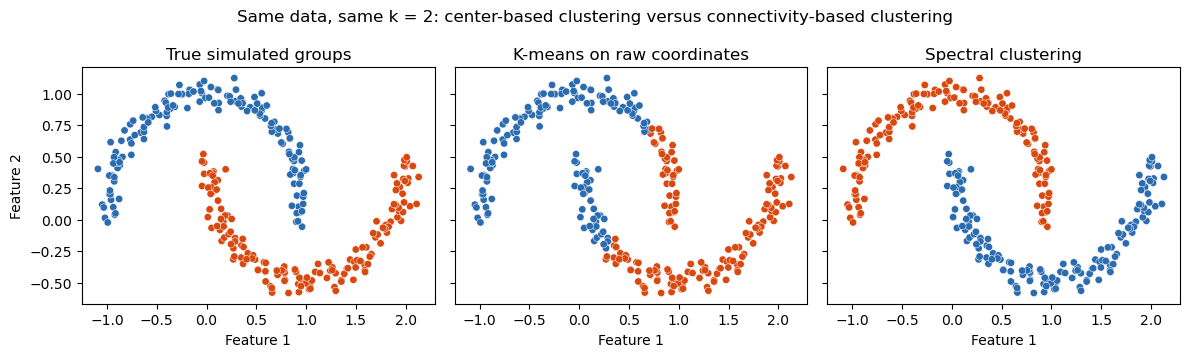

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.datasets import make_moons
from sklearn.metrics import adjusted_rand_score

# Simulated data: two interleaved crescents.
X, true_group = make_moons(n_samples=300, noise=0.06, random_state=4)

# Baseline: k-means on the raw coordinates.
kmeans = KMeans(n_clusters=2, n_init=20, random_state=0)
kmeans_labels = kmeans.fit_predict(X)

# Spectral clustering: RBF affinity creates a weighted similarity graph.
spectral = SpectralClustering(
    n_clusters=2,
    affinity="rbf",
    gamma=20,
    assign_labels="kmeans",
    random_state=0,
)
spectral_labels = spectral.fit_predict(X)

print(f"k-means  vs truth, adjusted Rand index: {adjusted_rand_score(true_group, kmeans_labels):.3f}")
print(f"spectral vs truth, adjusted Rand index: {adjusted_rand_score(true_group, spectral_labels):.3f}")

palette = ListedColormap(["#2B6CB0", "#D9480F"])
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharex=True, sharey=True)
plots = [
    (true_group, "True simulated groups"),
    (kmeans_labels, "K-means on raw coordinates"),
    (spectral_labels, "Spectral clustering"),
]
for ax, labels, title in zip(axes, [p[0] for p in plots], [p[1] for p in plots]):
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap=palette, s=28,
               edgecolor="white", linewidth=0.35)
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
fig.suptitle("Same data, same k = 2: center-based clustering versus connectivity-based clustering")
plt.tight_layout()
plt.show()


### What the graph changes

The graph view replaces the question "which center is closest?" with "which nearby points are connected to me?" The code below draws a small nearest-neighbor graph on the same two-moons data. It is not meant to be the only possible affinity choice; it is a picture of the idea.

Short edges stay mostly along each crescent. That is the visual reason spectral clustering can follow the moons: the graph contains two paths, not two round clouds.


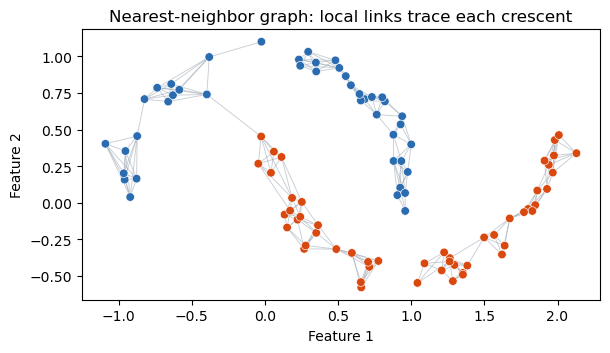

In [2]:
from matplotlib.collections import LineCollection
from sklearn.neighbors import kneighbors_graph

# Use a subset so the graph is readable on a slide/page.
rng = np.random.default_rng(2)
subset = np.sort(rng.choice(len(X), size=95, replace=False))
X_small = X[subset]
y_small = true_group[subset]

neighbors = kneighbors_graph(X_small, n_neighbors=6, mode="connectivity", include_self=False)
rows, cols = neighbors.nonzero()
edges = [(X_small[i], X_small[j]) for i, j in zip(rows, cols) if i < j]

fig, ax = plt.subplots(figsize=(6.2, 4.4))
ax.add_collection(LineCollection(edges, colors="#9AA5B1", linewidths=0.65, alpha=0.55))
ax.scatter(X_small[:, 0], X_small[:, 1], c=y_small, cmap=palette, s=38,
           edgecolor="white", linewidth=0.45, zorder=3)
ax.set_title("Nearest-neighbor graph: local links trace each crescent")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.autoscale()
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()


### What the eigenvectors do

The spectral embedding is the intermediate space created from the graph Laplacian eigenvectors. In the original coordinates, the two groups wrap around each other. In the spectral coordinates, the graph structure has been unfolded enough that the final k-means step is easy.


k-means in spectral embedding vs truth, adjusted Rand index: 1.000


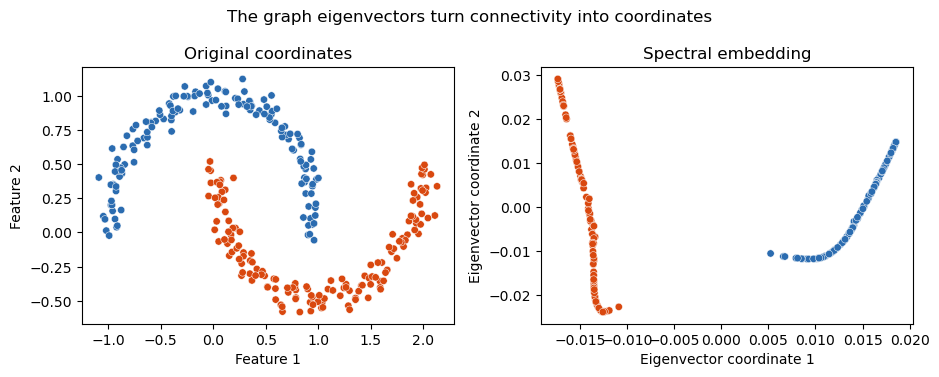

In [3]:
from sklearn.manifold import SpectralEmbedding

embedding = SpectralEmbedding(
    n_components=2,
    affinity="rbf",
    gamma=20,
    random_state=0,
).fit_transform(X)

embedding_labels = KMeans(n_clusters=2, n_init=20, random_state=0).fit_predict(embedding)
print(f"k-means in spectral embedding vs truth, adjusted Rand index: {adjusted_rand_score(true_group, embedding_labels):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8))
axes[0].scatter(X[:, 0], X[:, 1], c=true_group, cmap=palette, s=28,
                edgecolor="white", linewidth=0.35)
axes[0].set_title("Original coordinates")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

axes[1].scatter(embedding[:, 0], embedding[:, 1], c=true_group, cmap=palette, s=28,
                edgecolor="white", linewidth=0.35)
axes[1].set_title("Spectral embedding")
axes[1].set_xlabel("Eigenvector coordinate 1")
axes[1].set_ylabel("Eigenvector coordinate 2")
fig.suptitle("The graph eigenvectors turn connectivity into coordinates")
plt.tight_layout()
plt.show()


### Takeaway

Use spectral clustering when the clusters are better described as **connected pieces of a graph** than as round clouds around centers.

- K-means asks: which center is closest?
- Spectral clustering asks: which connected part of the similarity graph does this point belong to?
- The final k-means step is still present, but it runs after the graph has been converted into spectral coordinates.
